### Laboratorio de Escalonamento ###

Neste laboratório, iremos simular o funcionamento de algoritmos de escalonamento básicos para entender melhor seu funcionamento.

Na célula abaixo, temos uma classe Processo, que tem as informações de execução, e uma classe de exemplo de escalonamento apenas com os protótipos:

(orientação a objeto em Python)

In [ ]:
import numpy as np
import random

class Processo(object):
    def __init__(self,pnome,pio,ptam,prioridade,tempoChegada,bilhetes=0):
        self.nome = pnome
        self.io = pio # Probabilidade de fazer E/S, inicialmente zero
        self.tam = ptam # Quantos Timeslices sao necessarios para terminar
        self.prio = prioridade # Prioridade, eh desnecessaria agora
        self.chegada = 0

    def roda(self,quantum=None): # se rodar sem quantum, o processor roda ate o fim
        if(random.randint(1,100)<self.io): #Verifica se fez E/S
            self.tam-=1
            print(self.nome," fez e/s, falta ",self.tam)
            return 1, True #True que fez E/S


        if(quantum is None or self.tam<quantum):
            quantum = self.tam
        self.tam -=quantum
        print(self.nome," rodou por ",quantum," timeslice, faltam ",self.tam)
        return quantum, False # False se nao fez E/S


class escalonador(object): # Protótipo de escalonador de exemplo
    def __init__(self,vprontos=[]):
        self.prontos = vprontos #processos que cheam ao tempo zero

    def pronto(self,Processo):
        # implemente aqui o que escalonador faz quando surge um novo processo pronto

    def proximo(self):
        # implemente aqui a politica de escalonamento para definir um processo a ser executado
        return p #processo p eh escolhido



IndentationError: ignored

Na célula abaixo, são criados quatro processos completamente CPU-Bound que precisam de 3 timeslices para rodar.

O valor de E/S é um número entre 0 e 100 indicando quantos porcento de chance o processo tem de fazer E/S durante seu tempo na CPU

In [ ]:
nprocs = 4
nomes = ['A','B','C','D']
chanceio = [0,0,0,0] #Valor de zero a cem, chance de ser entrada e saida por enquanto deixem em zero
tamanho = np.array([3,3,3,3])


total = tamanho.sum()

procs = []
for i in range(nprocs):
    procs.append(Processo(nomes[i],chanceio[i],tamanho[i],0,0)) #cria uma lista procs de Processos

Na célula abaixo, temos o mesmo simulador do laboratório anterior:

In [ ]:
quantum = 2
tempoBloq = 1

escalonador = escalonador(procs) #troque escalonador pelo seu escalonador
bloqueados = []

tempo = 0

random.seed(0)

while total>0:
    p = escalonador.proximo()
    if(p is not None):
        rodou, _ = p.roda() #adicione quantum como parâmetro, por enquanto nao temos E/S

        if(p.tam>0):
            escalonador.pronto(p)
        total-=rodou
        tempo+=rodou
    else:
        #Reduz o tempo de todos os bloqueados em uma unidade se nao havia ninguem pronto
        tempo+=1




Nesta, temos um simulador avançado, com E/S e novos processos chegando em momentos diferentes:

In [ ]:
quantum = 2
tempoBloq = 2

escalonador = round_robin([])
bloqueados = []


maximo = 10
chanceNovoProcesso = 60
chanceIo = 30
minTime = 4
maxTime = 10


contaProc = 1
tempo = 0

#descomente essa linha caso queira que os random sempre dêem o mesmo resultado
random.seed(0)

while tempo<maximo or len(escalonador.prontos)>0:

    #Novo processo tem chanceProcesso% de chance surgir enquanto o tempo não chegar no máximo
    if(tempo<maximo and random.randint(1,100)<chanceNovoProcesso):
        p = Processo('P'+str(contaProc),random.randint(1,chanceIo),random.randint(minTime,maxTime),0,tempo)
        print("Processo",p.nome," chegou no tempo",tempo)
        escalonador.pronto(p)
        contaProc+=1


    p = escalonador.proximo()

    if(p is not None):
        rodou, fezio = p.roda(quantum)
        if(fezio and p.tam>0):
            bloqueados.append([p,tempoBloq+1]) #Adiciona o processo que fez e/s aos bloqueados
        elif(p.tam>0):
            escalonador.pronto(p)
        total-=rodou
        tempo+=rodou
    else:
        #Reduz o tempo de todos os bloqueados em uma unidade
        tempo+=1
    if(len(bloqueados)>0):
        for i in bloqueados:
            i[1]-=1
            if(i[1]==0):
                escalonador.pronto(i[0])
                del i

### Laboratório: ###

Neste laboratório vocês (em duplas) irão implementar 3 escalonadores:

1 - MLFQ: Adicione parâmetros para definir o número de filas, o quantum de cada uma e o tempo de boost.

2 - Loteria: tem um atributo `prioridade` no Processo, use ele para definir um número aleatório de bilhetes, similar ao que ocorre com e/s e outros parämetros

3 - Stride: Similar ao loteria.



# Loteria

In [ ]:
import numpy as np
import random

class Processo(object):
    def __init__(self,pnome,pio,ptam,tempoChegada,bilhetes=0):
        self.nome = pnome
        self.io = pio # Probabilidade de fazer E/S, inicialmente zero
        self.tam = ptam # Quantos Timeslices sao necessarios para terminar
        #self.prio = prioridade # Prioridade, eh desnecessaria agora
        self.chegada = 0
        self.bilhetes = bilhetes

    def roda(self,quantum=None): # se rodar sem quantum, o processor roda ate o fim
        if(random.randint(1,100)<self.io): #Verifica se fez E/S
            self.tam-=1
            print(self.nome," fez e/s, falta ",self.tam)
            return 1, True #True que fez E/S


        if(quantum is None or self.tam<quantum):
            quantum = self.tam
        self.tam -=quantum
        print(self.nome," rodou por ",quantum," timeslice, faltam ",self.tam)
        return quantum, False # False se nao fez E/S


class Loteria(object):
    def __init__(self, vprontos=[]):
        self.prontos = vprontos
        self.tempo_inicio_execucao = {}

    def pronto(self, processo):
        if processo.bilhetes > 0:
            self.prontos.append(processo)
            processo.chegada = len(self.prontos) - 1

    def proximo(self):
        self.prontos = [p for p in self.prontos if p.tam > 0 and p.bilhetes > 0]
        total_bilhetes = sum([p.bilhetes for p in self.prontos])

        if total_bilhetes == 0:
            return None

        random.seed()
        numero_sorteado = random.randint(1, total_bilhetes)

        limite_inferior = 0
        for processo in self.prontos:
            limite_superior = limite_inferior + processo.bilhetes
            if limite_inferior < numero_sorteado <= limite_superior:
                processo.bilhetes -= 1
                return processo
            limite_inferior = limite_superior

        return None

In [ ]:
nprocs = 2
nomes = ['A','B']#,'C','D']
chanceio = [0,0]#,0,0] #Valor de zero a cem, chance de ser entrada e saida por enquanto deixem em zero
tamanho = np.array([100,100])
bilhetes = [100, 100]

total = tamanho.sum()

procs = []
for i in range(nprocs):
    procs.append(Processo(nomes[i], chanceio[i], tamanho[i], 0, bilhetes[i])) #cria uma lista procs de Processoss

In [ ]:
quantum = 2
tempoBloq = 1

escalonador = Loteria(procs) #troque escalonador pelo seu escalonador
bloqueados = []

tempo = 0

tempo_resposta = {}
tempo_execucao = {}
while total > 0:
    p = escalonador.proximo()
    if p is not None:
        if p not in escalonador.tempo_inicio_execucao:
            escalonador.tempo_inicio_execucao[p] = tempo - p.chegada

        rodou, _ = p.roda(quantum)

        if p.tam > 0:
            escalonador.pronto(p)
        else:
            tempo_execucao[p] = tempo - p.chegada  # Calcula o tempo de execução corretamente
        total -= rodou
        tempo += rodou
    else:
        tempo += 1

# Imprime os tempos de resposta e execução de cada processo
# for processo in procs:
#     print(f"Processo {processo.nome}: Tempo de Resposta = {escalonador.tempo_inicio_execucao[processo]}, Tempo de Execução = {tempo_execucao[processo]}")

A  rodou por  2  timeslice, faltam  98
A  rodou por  2  timeslice, faltam  96
A  rodou por  2  timeslice, faltam  94
A  rodou por  2  timeslice, faltam  92
A  rodou por  2  timeslice, faltam  90
A  rodou por  2  timeslice, faltam  88
A  rodou por  2  timeslice, faltam  86
A  rodou por  2  timeslice, faltam  84
A  rodou por  2  timeslice, faltam  82
A  rodou por  2  timeslice, faltam  80
A  rodou por  2  timeslice, faltam  78
A  rodou por  2  timeslice, faltam  76
A  rodou por  2  timeslice, faltam  74
A  rodou por  2  timeslice, faltam  72
A  rodou por  2  timeslice, faltam  70
A  rodou por  2  timeslice, faltam  68
A  rodou por  2  timeslice, faltam  66
A  rodou por  2  timeslice, faltam  64
A  rodou por  2  timeslice, faltam  62
B  rodou por  2  timeslice, faltam  98
A  rodou por  2  timeslice, faltam  60
A  rodou por  2  timeslice, faltam  58
A  rodou por  2  timeslice, faltam  56
A  rodou por  2  timeslice, faltam  54
A  rodou por  2  timeslice, faltam  52
A  rodou por  2  timeslic

# Stride Scheduler

In [ ]:
import numpy as np
import random

class Processo(object):
    def __init__(self, pnome, pio, ptam, prioridade, tempoChegada, passos=0):
        self.nome = pnome
        self.io = pio
        self.tam = ptam
        self.prio = prioridade
        self.chegada = 0
        self.passos = passos

    def roda(self,quantum=None): # se rodar sem quantum, o processor roda ate o fim
        if(random.randint(1,100)<self.io): #Verifica se fez E/S
            self.tam-=1
            print(self.nome," fez e/s, falta ",self.tam)
            return 1, True #True que fez E/S


        if(quantum is None or self.tam<quantum):
            quantum = self.tam
        self.tam -=quantum
        print(self.nome," rodou por ",quantum," timeslice, faltam ",self.tam)
        return quantum, False # False se nao fez E/S


class StrideScheduler(object):
    def __init__(self, vprontos=[]):
        self.prontos = vprontos
        self.tempo_inicio_execucao = {}

    def pronto(self, processo):
        self.prontos.append(processo)
        processo.chegada = len(self.prontos) - 1

    def proximo(self):

        self.prontos = [p for p in self.prontos if p.tam > 0]

        if not self.prontos:
            return None

        min_proporcao = min(p.passos / p.tam for p in self.prontos)
        processos_min_proporcao = [p for p in self.prontos if p.passos / p.tam == min_proporcao]
        processo_selecionado = random.choice(processos_min_proporcao)
        processo_selecionado.passos += processo_selecionado.prio

        return processo_selecionado


In [ ]:
nprocs = 2
nomes = ['A','B']#,'C']#,'D']
chanceio = [0,0]#,0]#,0] #Valor de zero a cem, chance de ser entrada e saida por enquanto deixem em zero
tamanho = np.array([100,100])#,16])#,12])
prioridades = tamanho  # neste caso arbitrário as prioridades são iguais ao tamanho

total = tamanho.sum()

procs = []
for i in range(nprocs):
    procs.append(Processo(nomes[i], chanceio[i], tamanho[i], prioridades[i], 0, 0)) #cria uma lista procs de Processoss

In [ ]:
quantum = 100
tempoBloq = 1

escalonador = StrideScheduler(procs) #troque escalonador pelo seu escalonador
bloqueados = []

tempo = 0

tempo_resposta = {}
tempo_execucao = {}
while total > 100:
    p = escalonador.proximo()
    if p is not None:
        if p not in escalonador.tempo_inicio_execucao:
            escalonador.tempo_inicio_execucao[p] = tempo - p.chegada

        rodou, _ = p.roda(quantum)

        if p.tam > 0:
            escalonador.pronto(p)
        else:
            tempo_execucao[p] = tempo - p.chegada  # Calcula o tempo de execução corretamente
        total -= rodou
        tempo += rodou
    else:
        tempo += 1

# Imprime os tempos de resposta e execução de cada processo
# for processo in procs:
#     print(f"Processo {processo.nome}: Tempo de Resposta = {escalonador.tempo_inicio_execucao[processo]}, Tempo de Execução = {tempo_execucao[processo]}")

B  rodou por  100  timeslice, faltam  0


# MLFQ

In [ ]:
import numpy as np
import random

class Processo(object):
    def __init__(self, pnome, pio, ptam, prioridade, tempoChegada):
        self.nome = pnome
        self.io = pio
        self.tam = ptam
        self.prio = prioridade
        self.chegada = tempoChegada

    def roda(self, quantum=None):
        if random.randint(1, 100) < self.io:
            self.tam -= 1
            print(self.nome, " fez e/s, falta ", self.tam)
            return 1, True

        if quantum is None or self.tam < quantum:
            quantum = self.tam
        self.tam -= quantum
        print(self.nome, " rodou por ", quantum, " timeslice, faltam ", self.tam)
        return quantum, False

class MLFQ(object):
    def __init__(self, num_queues, boost_interval):
        self.num_queues = num_queues
        self.queues = [[] for _ in range(num_queues)]
        self.timer = 0
        self.boost_interval = boost_interval

    def pronto(self, processo):
        self.queues[0].append(processo)

    def proximo(self):
        for i in range(self.num_queues):
            if self.queues[i]:
                return self.queues[i].pop(0)
        return None

    def envelhecer_processos(self):
        for i in range(1, self.num_queues):
            for processo in self.queues[i]:
                processo.prio += 1

    def realizar_boost(self):
        if self.timer >= self.boost_interval:
            for queue in self.queues:
                queue.extend(self.queues[self.num_queues - 1])
            self.timer = 0
        else:
            self.timer += 1


In [ ]:
nprocs = 4
nomes = ['A', 'B', 'C', 'D']
chanceio = [0, 0, 0, 0]
tamanho = np.array([4, 4, 4, 4])
prio = [100, 120, 150, 50]
total = tamanho.sum()

procs = []
for i in range(nprocs):
    procs.append(Processo(nomes[i], chanceio[i], tamanho[i], prio[i], 0))

In [ ]:
quantum = 2
tempoBloq = 2

mlfq = MLFQ(num_queues=3, boost_interval=3)
bloqueados = []

maximo = 10
chanceNovoProcesso = 60
chanceIo = 30
minTime = 4
maxTime = 10

contaProc = 1
tempo = 0

while tempo < maximo or any(mlfq.queues):
    if tempo < maximo and random.randint(1, 100) < chanceNovoProcesso:
        p = Processo('P' + str(contaProc), random.randint(1, chanceIo), random.randint(minTime, maxTime), 0,
                      tempo)
        print("Processo", p.nome, " chegou no tempo", tempo)
        mlfq.pronto(p)
        contaProc += 1

    mlfq.envelhecer_processos()

    p = mlfq.proximo()

    if p is not None:
        rodou, fezio = p.roda(quantum)
        if fezio and p.tam > 0:
            bloqueados.append([p, tempoBloq + 1])
        elif p.tam > 0:
            mlfq.pronto(p)
        total -= rodou
        tempo += rodou
    else:
        tempo += 1

    if len(bloqueados) > 0:
        bloqueados = [[p, t - 1] for p, t in bloqueados if t > 1]
        for i in bloqueados:
            if i[1] == 0:
                mlfq.pronto(i[0])

Processo P1  chegou no tempo 3
P1  fez e/s, falta  4
Processo P2  chegou no tempo 6
P2  rodou por  2  timeslice, faltam  5
P2  rodou por  2  timeslice, faltam  3
P2  rodou por  2  timeslice, faltam  1
P2  rodou por  1  timeslice, faltam  0


# Responda #

#### Sobre Loteria: ####

1 - Rode a simulação mais simples com apenas dois processos, um com 100 tickets e outro com 1, com tempo 100 para terminar. O que aconteceu? O segundo processo conseguiu rodar alguma vez? Testando com outras sementes o resultado se manteve?

2 - Rode a simulação simples com dois processos com 100 tickets e 100 timeslices. Calcule a Unfairness para quantum=2. Repita a operação para quantum 10, 20, 50 e 100. O que aconteceu?

3 - Rode novamente dois processos com 100 tickets no simulador simples e quantum=2. Calcule a unfairness conforme o tamanho dos processos aumenta e faça um gráfico similar ao dos slides.

4 - Rode o simulador maior com três tipos de processo possíveis: um com 10 tickets, um com 20 e um com 50. O que aconteceu com os que receberam menos tickets? Eles tiveram chance de rodar?

Resposta 1 -  O segundo processo pode não rodar dependendo da semente aleatória fornecida, a chance de não rodar é de 1/101 o que é baixa, porém dependendo da semente (seed), pode ocorrer.

Resposta 2 - O indicador de Unfairness não mudou significativamente com a mudança do tamanho do quantum, ele se manteve próximo de 1 devido ao tamanho dos processos.

Resposta 3 -





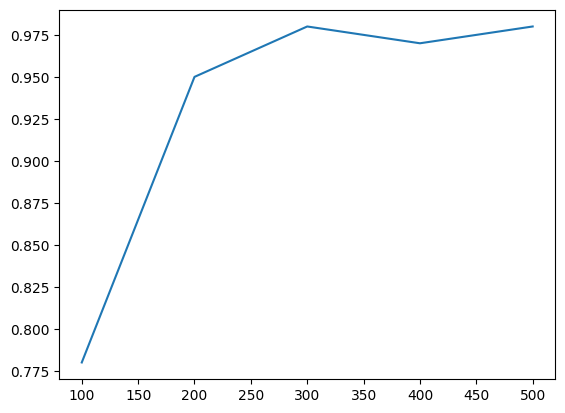

In [ ]:
import matplotlib.pyplot as plt

unfairness = [156/200, 190/200, 196/200, 194/200, 196/200]
tamanho = [100, 200, 300, 400, 500]
plt.plot(tamanho, unfairness)
plt.show()

Resposta 4 - Neste caso eles tiveram chance de rodar, se o processo tiver ao menos 1 ticket e se der o tempo para a aleatoriedade funcionar, ele irá rodar.

#### Sobre Stride ####

1 - Repita o cenário da 2 de loteria e faça um novo gráfico.

2 - No simulador maior, qual o efeito que ter muitos processos fazendo E/S tem no algoritmo? O que pode ser feito com a posição do processo quando ele volta de E/S?

3 - No simulador maior, rode um cenário igual para stride e loteria (com a mesma semente aleatória) e calcule tempo de resposta, de execução e __tempo de espera__ (tempo que o processo passou pronto). O que mudou entre os dois?

Resposta 1 -

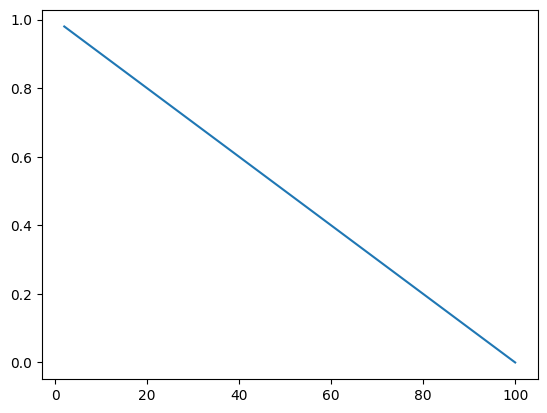

In [ ]:
import matplotlib.pyplot as plt

unfairness = [49/50, 9/10, 4/5, 1/2, 0]
quantum = [2, 10, 20, 50, 100]
plt.plot(quantum, unfairness)
plt.show()

Resposta 2 - O atraso na execução dos processos é causada pelo acúmulo de processos. Um processo pode voltar ao início da fila, como se não tivesse sido avançado.

Resposta 3 - Apesar do tempo de espera e de execução menores, o tempo de resposta do Stride foi menor.

#### Sobre MLFQ ####

1 - Rode o MLFQ no segundo simulador com duas filas e sem boost. O que aconteceu?

2 - Quais configurações de parâmetros transformam o MLFQ no Round Robin?

3 - Rodando no primeiro simulador, faça 1 dos quatro processos ser 100\% CPU-Bound e os outros três 60\% I/O Bound. Use a configuração com 3 filas, com 5, 3 e 1 timeslices para as fila em ordem de priorida. De quanto tempo deve ser o Boost para que o processo CPU-Bound não sofra starvation e tenha CPU 1 vez a cada 20 timeslices?

4 - Teste diversas configurações de número de filas, quantum das filas e boost no simulador maior e ache a que leva ao melhor tempo de execução.

Resposta 1 - Os processos que são iniciados primeiro demoram a serem executados pela CPU o que piora à medida que chega um número maior de processos novos.

Resposta 2 - Para que o MLFQ se transforme no Round Robin, basta deixar o parâmetro S (tempo para o boost) bem pequeno. Com isso, todos os processos estarão em prioridade alta a todo momento, fazendo com um lembre o outro.

Resposta 3 -

Resposta 4 - No caso de somente uma fila de prioridade, o MLFQ rodaria muito similar ao Round Robin, nesse caso, levando em consideração apenas o tempo de execução, Round Robin seria melhor.